# Week3 — GraphRAG 외부 DB 구축 및 검증

2주차 `rag_chunks.jsonl`(37 chunk)에서 LLM으로 **triplet (주어, 관계, 목적어)** 을
추출해 **NetworkX 지식 그래프**를 구축하고, 관계 추출 정확도와 그래프 연결성을 검증합니다.

기술 스택은 **bsvibe-app** 의 지식 그래프 파이프라인을 옮겼습니다.

| 영역 | 구현 | bsvibe 원본 |
| --- | --- | --- |
| triplet 추출 | `litellm` JSON 계약 | `backend/knowledge/ingest/llm_extractor.py` |
| 개체명 정제 | `normalize_name` + alias | `graph_models.normalize_name`, `graph/vault_backend.py` |
| 그래프 | NetworkX `MultiDiGraph` | `graph/vault_backend.py` |

**검증 항목**
1. triplet 스키마 무결성 — `(주어, 관계, 목적어)` 형식, None/빈값이 DB에 안 들어가게 방어
2. 개체명 중복 제거 — 동일 개체의 다른 표기를 한 노드로 통합
3. 토폴로지 — 총 노드/엣지 수 + NetworkX 시각화 + 연결성

> 그래프는 `build_graph_db.py` 가 생성·저장한 `data/knowledge_graph.json` 을 로드합니다
> (LLM 재호출 없이 **재현 가능**). 추출 파이프라인 자체는 `scripts/graph_store.py`.


In [1]:
import json, sys
from collections import Counter
from pathlib import Path

import networkx as nx
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / ".git").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
BASE = REPO_ROOT / "assignments" / "week3-rag-db"
sys.path.insert(0, str(BASE / "scripts"))

from graph_store import Entity, KnowledgeGraph, parse_triplets

G = nx.node_link_graph(
    json.loads((BASE / "data" / "knowledge_graph.json").read_text()),
    edges="links", multigraph=True, directed=True,
)
report = json.loads((BASE / "data" / "graph_report.json").read_text())
print("그래프 로드:", G.number_of_nodes(), "노드 /", G.number_of_edges(), "엣지")


그래프 로드: 272 노드 / 226 엣지


## 검증 ① — triplet 스키마 및 무결성

`parse_triplets` 는 LLM 응답을 방어적으로 파싱합니다. `(주어, 관계, 목적어)` 중 하나라도 None/빈 문자열이면 그래프에 넣지 않고 **거부 카운트**로 남깁니다. 깨진 JSON 도 크래시 없이 빈 결과로 처리합니다. 의도적으로 망가진 입력으로 시연합니다.

In [2]:
bad_payload = json.dumps({
    "entities": [
        {"name": "KnowledgeFactory", "entity_type": "component"},  # 정상
        {"name": "", "entity_type": "component"},                  # 빈 이름 → 거부
        {"name": None, "entity_type": "tool"},                     # None → 거부
        {"name": "Vault", "entity_type": ""},                      # 빈 타입 → 거부
    ],
    "relationships": [
        {"source": "KnowledgeFactory", "target": "Vault", "rel_type": "constructs"},  # 정상
        {"source": "A", "target": "", "rel_type": "uses"},          # 빈 target → 거부
        {"source": None, "target": "B", "rel_type": "uses"},        # None source → 거부
    ],
})
res = parse_triplets(bad_payload)
print("통과한 entity     :", [(e.name, e.entity_type) for e in res.entities])
print("통과한 relationship:", [(r.source, r.rel_type, r.target) for r in res.relationships])
print("거부된 entity 수   :", res.rejected_entities)
print("거부된 relationship:", res.rejected_relationships)
print()
print("깨진 JSON 처리:", parse_triplets("not json {{{"))  # 크래시 X


통과한 entity     : [('KnowledgeFactory', 'component')]
통과한 relationship: [('KnowledgeFactory', 'constructs', 'Vault')]
거부된 entity 수   : 3
거부된 relationship: 2

2026-06-05 18:23:42 [warning  ] triplet_parse_failed           raw_preview='not json {{{'


깨진 JSON 처리: ExtractionResult(entities=[], relationships=[], rejected_entities=0, rejected_relationships=0, parse_ok=False)


In [3]:
# 실제 37 chunk 빌드 시 무결성 통계 (build_graph_db.py 가 기록)
print("=== 실제 빌드 무결성 (37 chunk) ===")
print("거부된 entity        :", report["rejected_entities"])
print("거부된 relationship  :", report["rejected_relationships"])
print("JSON 파싱 실패 chunk  :", report["parse_failures"])
print()
# 그래프에 실제로 None/빈 이름 노드가 없는지 재확인
empty_nodes = [n for n, a in G.nodes(data=True) if not str(a.get("name", "")).strip()]
print("그래프 내 빈 이름 노드:", len(empty_nodes), "→ ✅ 무결" if not empty_nodes else "⚠️")


=== 실제 빌드 무결성 (37 chunk) ===
거부된 entity        : 0
거부된 relationship  : 0
JSON 파싱 실패 chunk  : 0

그래프 내 빈 이름 노드: 0 → ✅ 무결


## 검증 ② — 개체명 중복 제거 (Entity Resolution)

'이순신/이순신 장군/충무공' 처럼 동일 개체를 가리키는 다른 표기를 한 노드로 통합하는지 확인합니다. 우리 도메인(BSVibe)판으로 시연한 뒤, 실제 빌드의 정제 퍼널을 봅니다.

In [4]:
# 시연: 동일 개체의 다양한 표기 → 1 노드
demo = KnowledgeGraph()
demo.register_aliases("KnowledgeFactory", ["knowledge factory", "knowledge-factory", "the knowledge factory"])
for surface, etype in [
    ("KnowledgeFactory", "component"),
    ("knowledge factory", "concept"),     # 대소문자+공백 표기 흔들림
    ("knowledge-factory", "module"),       # 하이픈 표기
    ("the knowledge factory", "component"),# 관사 포함
    ("KNOWLEDGEFACTORY", "component"),      # 전부 대문자
]:
    demo.upsert_entity(Entity(name=surface, entity_type=etype))

print("입력 표기 5종 → 노드 수:", demo.num_nodes())
nid = list(demo.graph.nodes)[0]
print("통합된 노드:", demo.graph.nodes[nid]["name"])
print("누적된 entity_types:", demo.graph.nodes[nid]["entity_types"])
assert demo.num_nodes() == 1
print("\n✅ 5종 표기가 normalize_name + alias 로 단일 노드에 통합")


입력 표기 5종 → 노드 수: 1
통합된 노드: KnowledgeFactory
누적된 entity_types: ['component', 'concept', 'module']

✅ 5종 표기가 normalize_name + alias 로 단일 노드에 통합


In [5]:
print("=== 실제 빌드 개체명 정제 퍼널 (37 chunk) ===")
print(f"entity mention 총합     : {report['raw_entity_mentions']}")
print(f"distinct 표기(raw)      : {report['distinct_raw_surfaces']}")
print(f"  → normalize_name 후   : {report['after_normalize']}")
print(f"  → alias 환원 후        : {report['after_alias']}  (= entity 노드 수)")
print()
print("주: BSVibe 코드 기반 텍스트라 LLM 이 비교적 일관된 표기를 내, 실데이터에선")
print("정제량이 작습니다. 위 시연이 메커니즘(표기 흔들림→단일 노드)을 직접 보여줍니다.")


=== 실제 빌드 개체명 정제 퍼널 (37 chunk) ===
entity mention 총합     : 290
distinct 표기(raw)      : 267
  → normalize_name 후   : 266
  → alias 환원 후        : 266  (= entity 노드 수)

주: BSVibe 코드 기반 텍스트라 LLM 이 비교적 일관된 표기를 내, 실데이터에선
정제량이 작습니다. 위 시연이 메커니즘(표기 흔들림→단일 노드)을 직접 보여줍니다.


## 검증 ③ — 지식 그래프 토폴로지(구조)

총 노드/엣지 수, 컴포넌트 분포, 허브 노드를 출력하고 NetworkX 시각화로 연결성을 검증합니다.

In [6]:
n, e = G.number_of_nodes(), G.number_of_edges()
comps = sorted((len(c) for c in nx.weakly_connected_components(G)), reverse=True)
print(f"총 노드 수            : {n}")
print(f"총 엣지 수            : {e}")
print(f"weakly connected comp : {len(comps)}")
print(f"최대 컴포넌트         : {comps[0]} 노드 ({100*comps[0]/n:.1f}%)")
print(f"컴포넌트 크기 상위 10  : {comps[:10]}")
print(f"단일 노드(고립) 수    : {sum(1 for c in comps if c == 1)}")
print()
deg = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]
print("허브 노드(degree 상위 10):")
for nid, d in deg:
    print(f"  {d:>3}  {G.nodes[nid].get('name')}")
rels = Counter(a.get("rel_type") for *_ , a in G.edges(data=True))
print("\n관계 타입 분포:", dict(rels.most_common(8)))


총 노드 수            : 272
총 엣지 수            : 226
weakly connected comp : 49
최대 컴포넌트         : 66 노드 (24.3%)
컴포넌트 크기 상위 10  : [66, 16, 14, 11, 10, 10, 10, 9, 8, 8]
단일 노드(고립) 수    : 11

허브 노드(degree 상위 10):
   12  RAG dataset
   10  compose.prod.yaml
    9  knowledge MCP domain tools
    8  IngestCompiler
    8  lint module
    8  EventType enums
    7  BSVibe
    7  SettleWorker
    6  RetractionSignal
    6  InspectorActions

관계 타입 분포: {'related_to': 50, 'produces': 28, 'uses': 22, 'exposes': 17, 'depends_on': 17, 'defines': 10, 'constructs': 8, 'part_of': 6}


### 전체 그래프 시각화

연결된 코어 + 주변 파편을 있는 그대로 보여줍니다 (정직한 토폴로지).

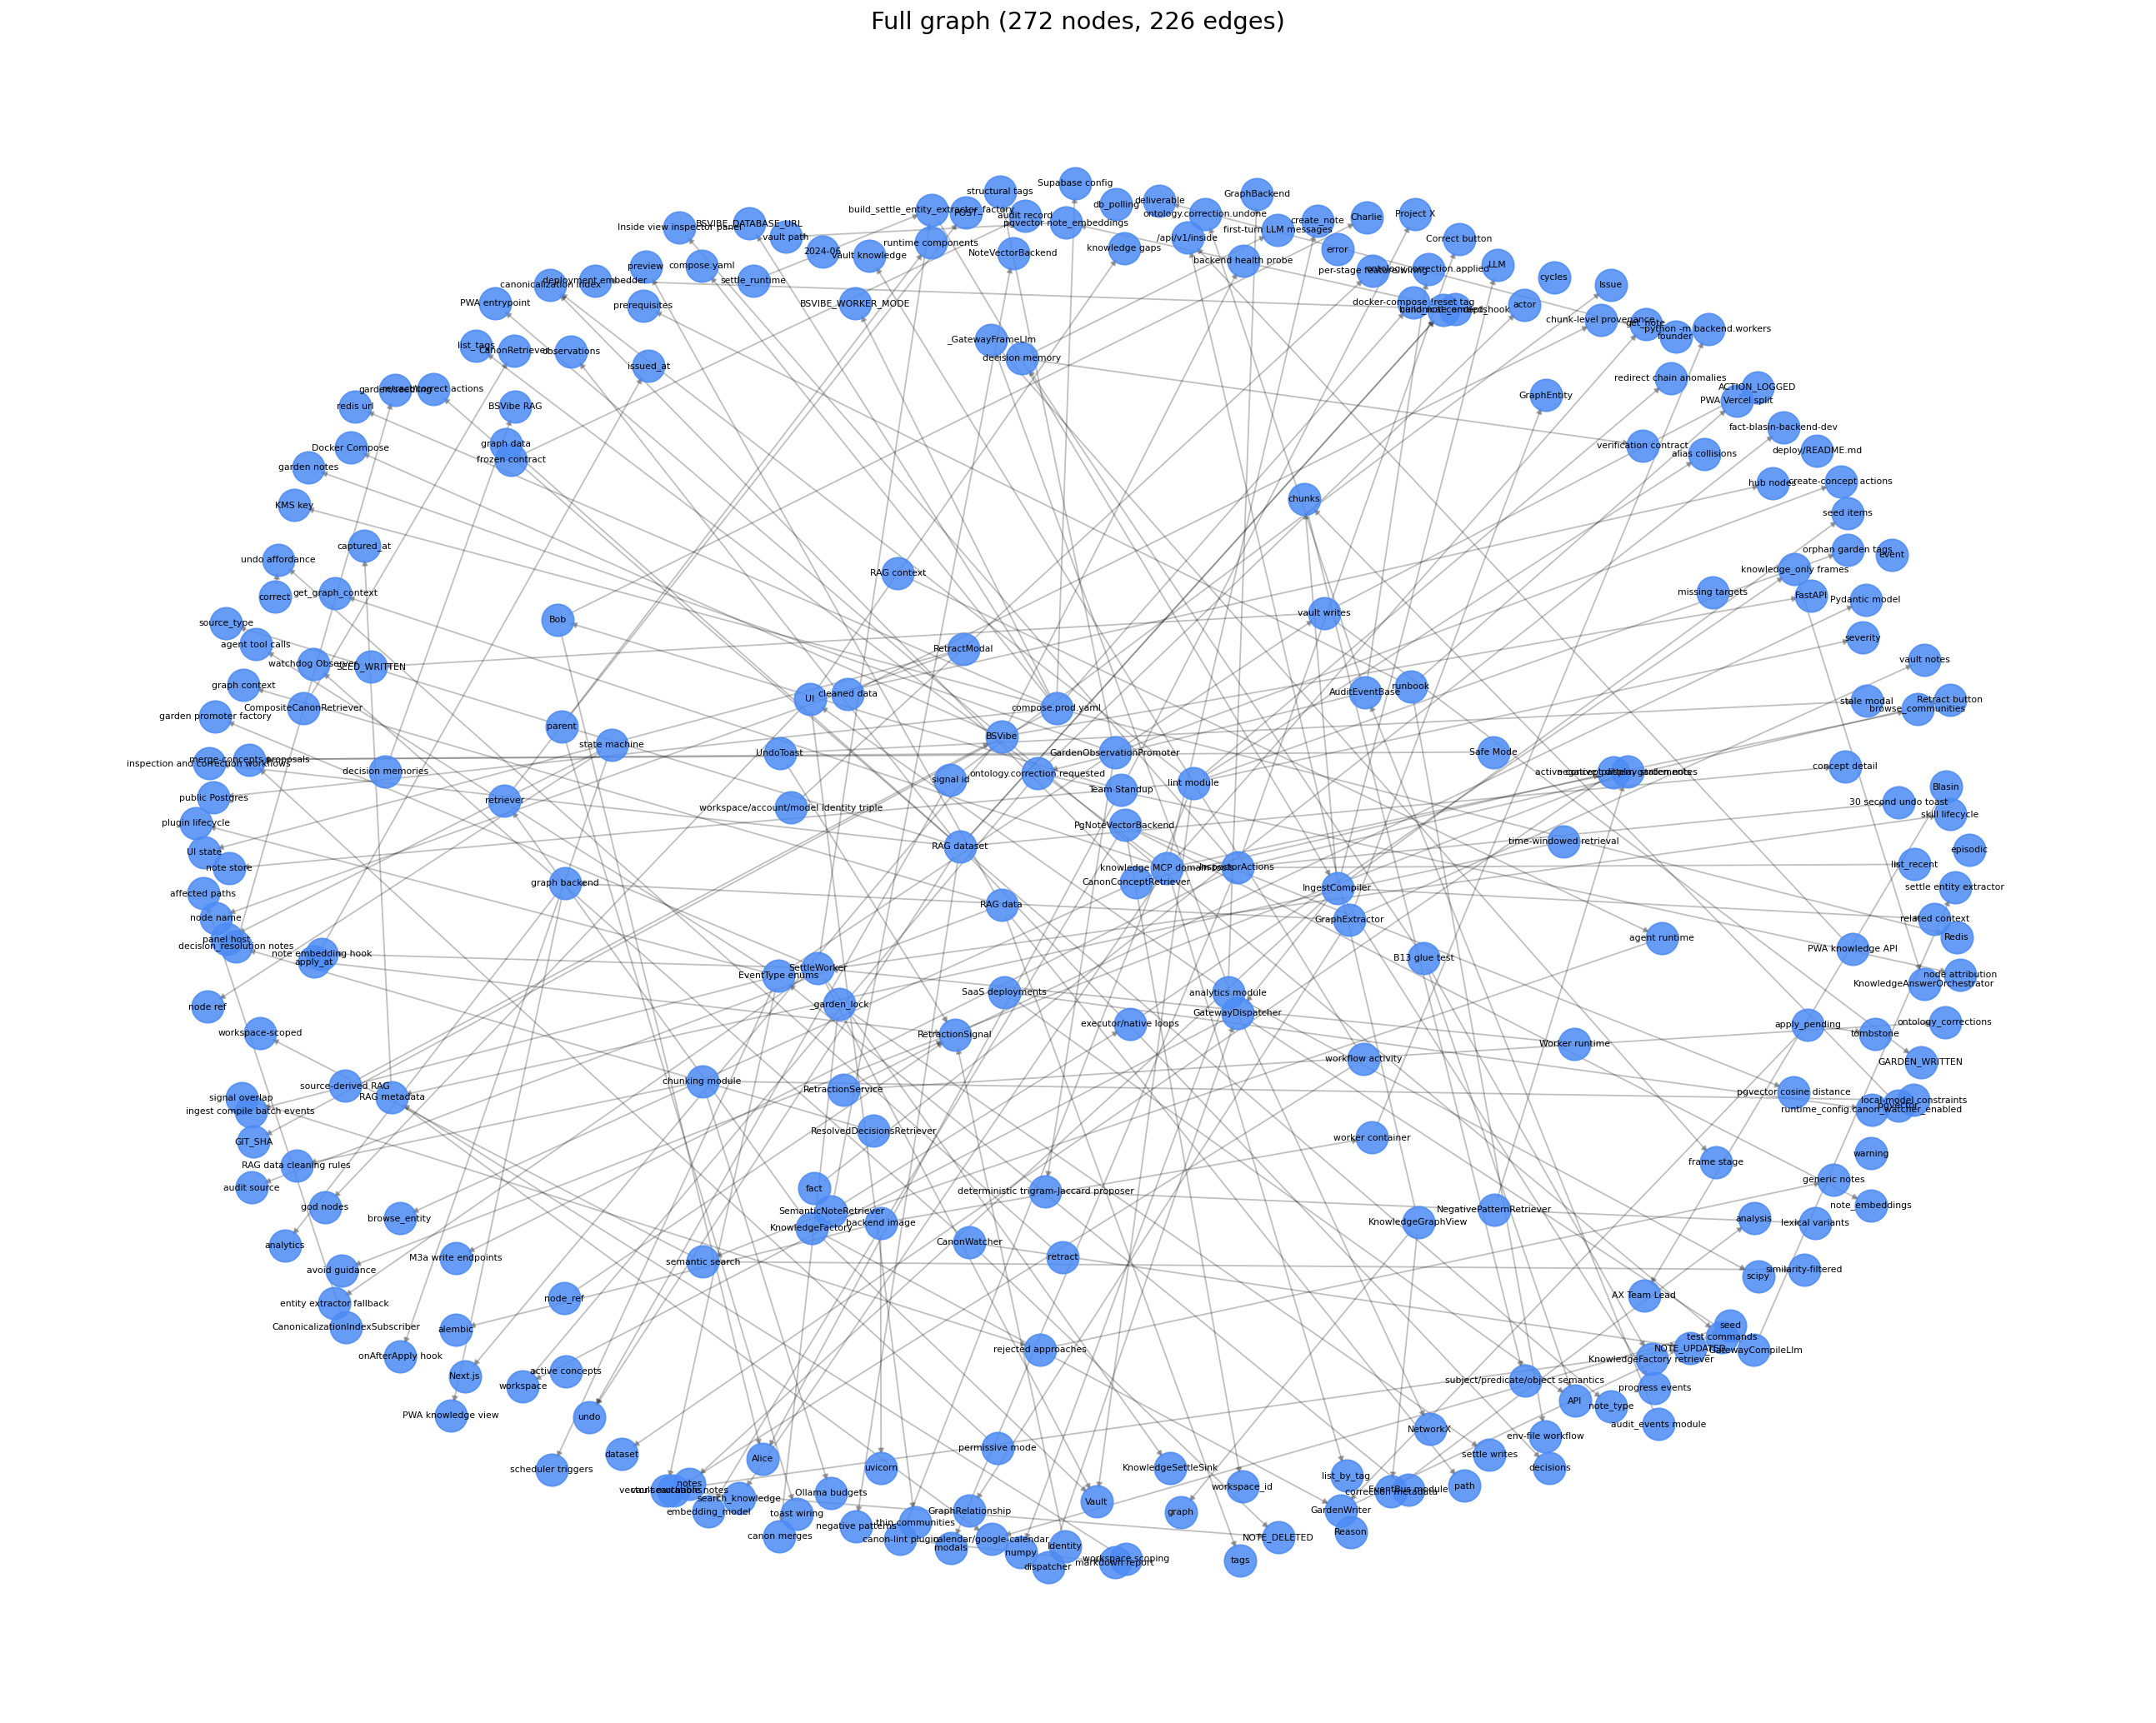

In [7]:
display(Image(filename=str(BASE / "reports" / "knowledge_graph.png")))

### 최대 연결 컴포넌트 (코어)

라벨이 읽히는 코어 — 컴포넌트 내부 연결 고리를 직관적으로 검증.

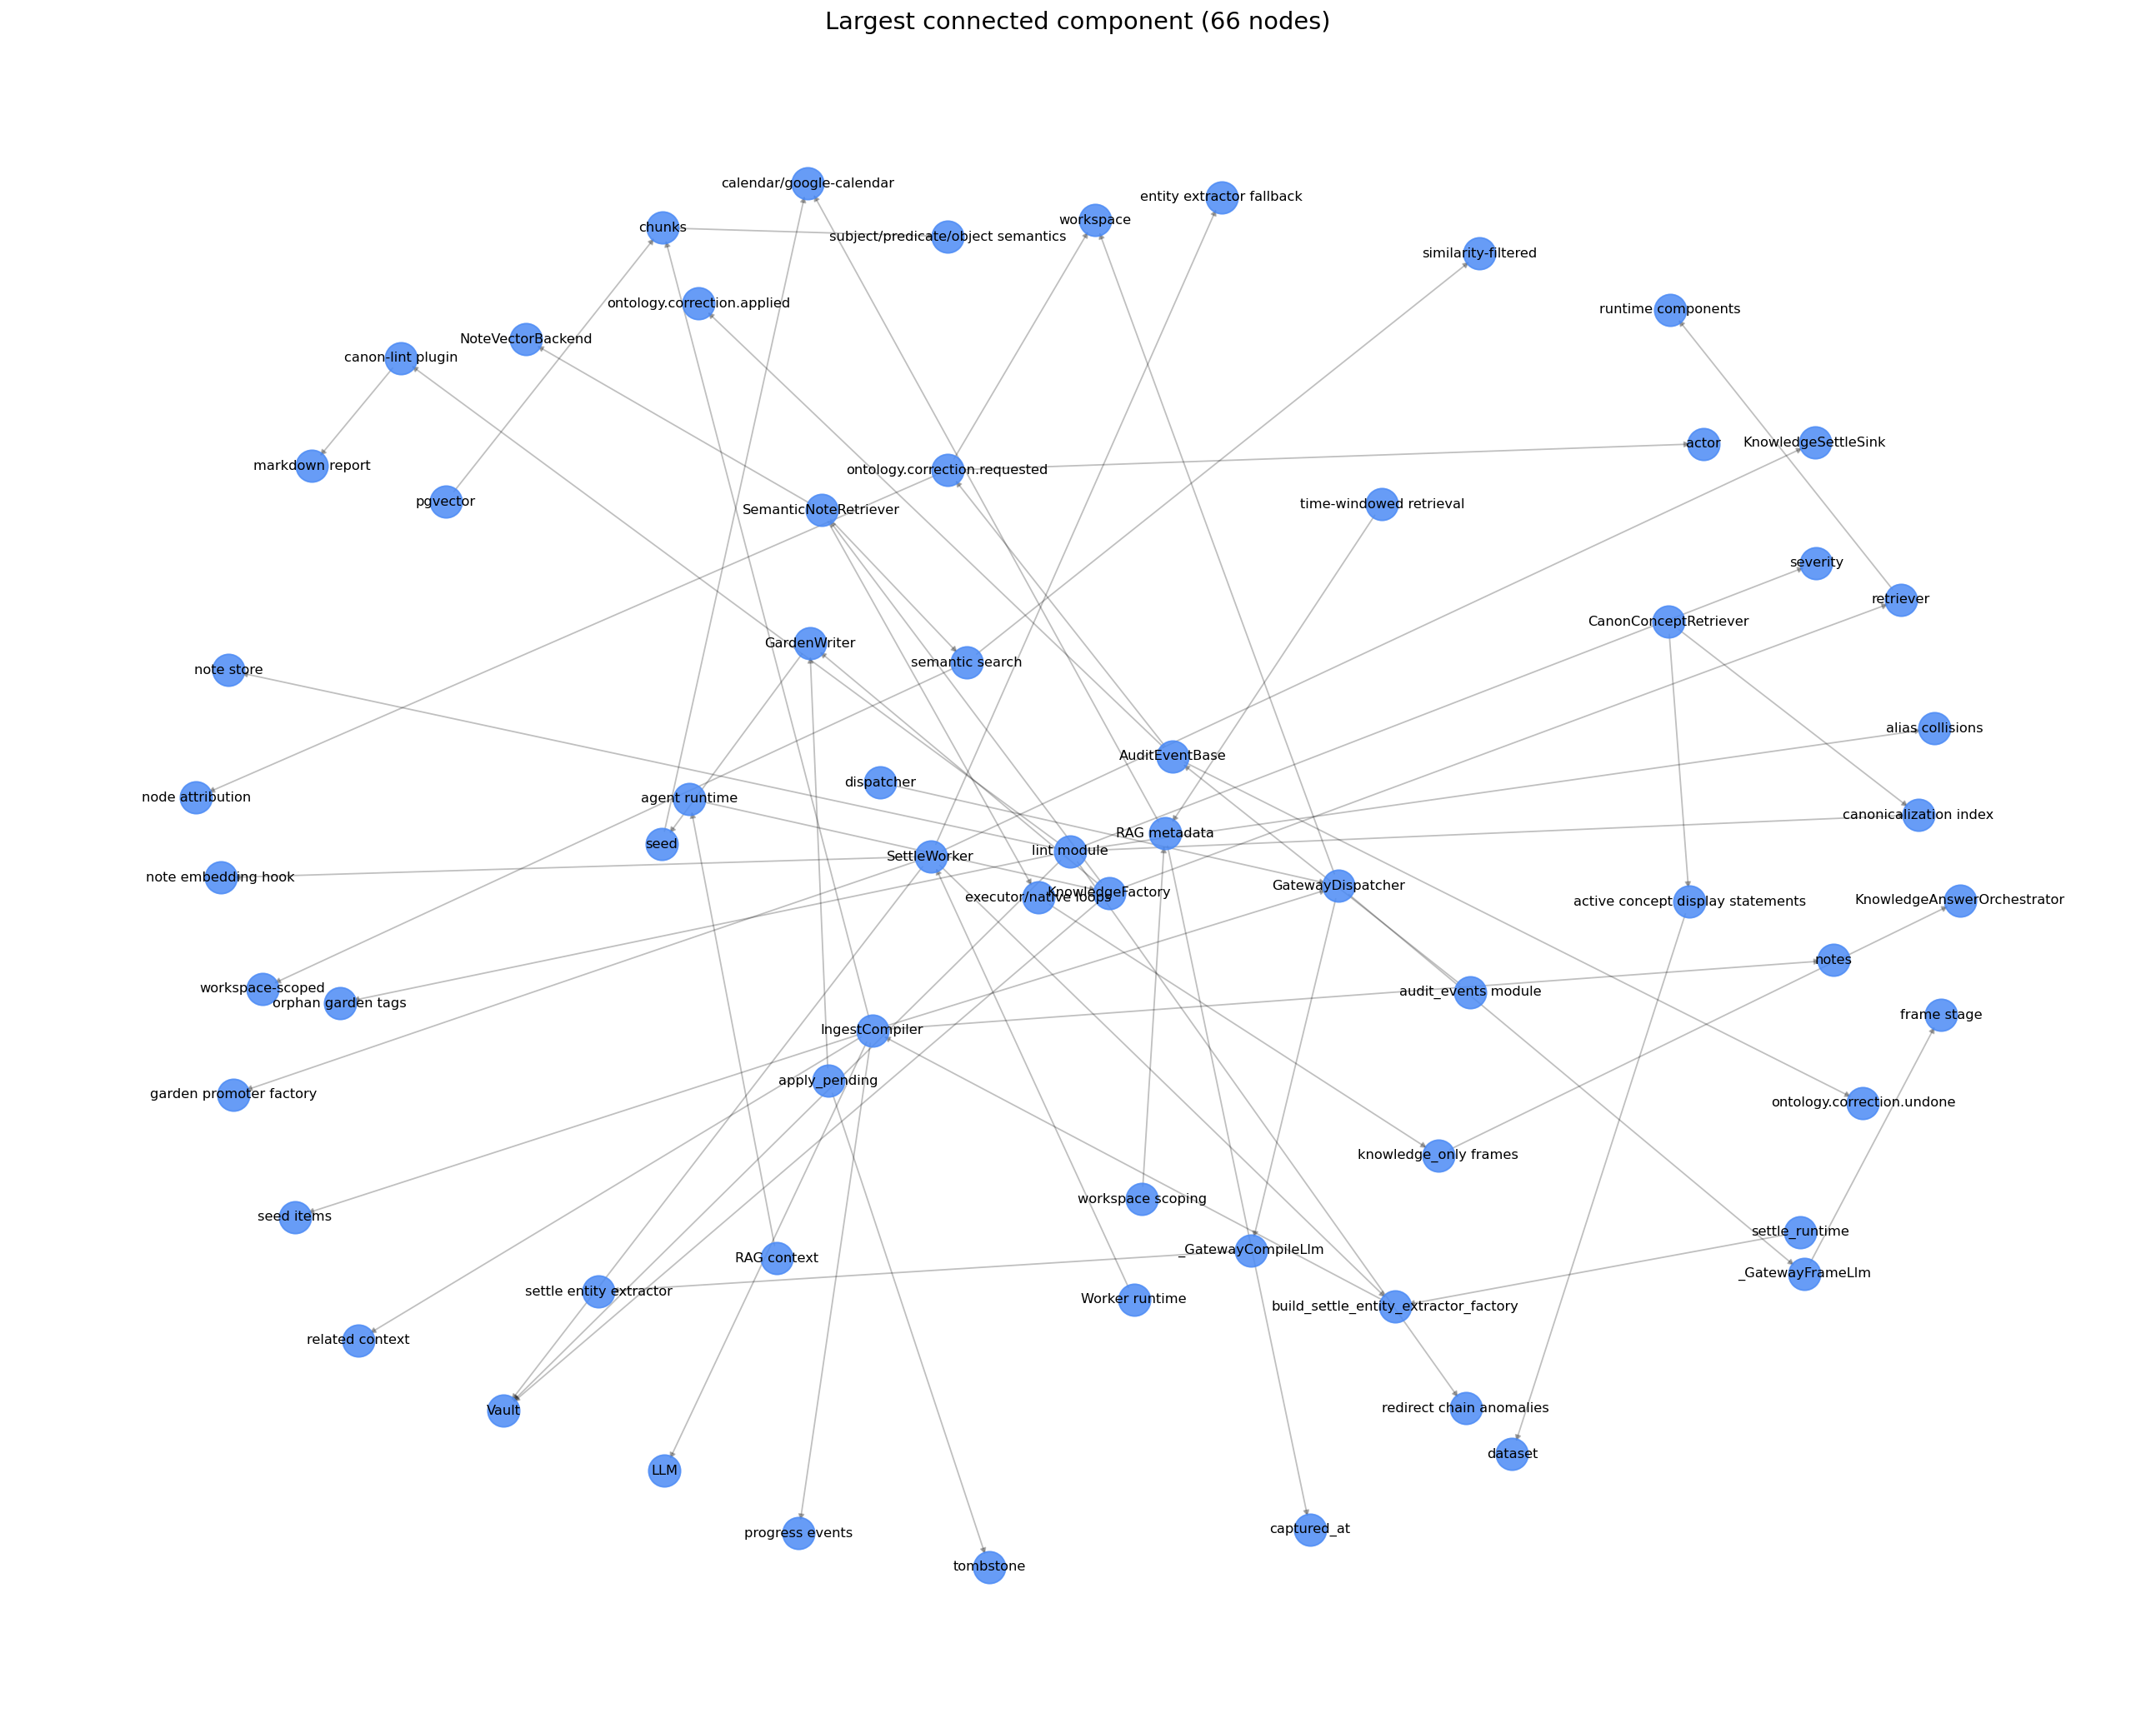

In [8]:
display(Image(filename=str(BASE / "reports" / "knowledge_graph_core.png")))

## 결론 (GraphRAG)

- **① triplet 무결성**: `parse_triplets` 가 None/빈 `(주어,관계,목적어)` 를 거부하고 깨진 JSON 도 안전 처리. 실제 37 chunk 빌드에서 거부 0 · 파싱 실패 0, 그래프 내 빈 이름 노드 0. ✅
- **② 개체명 중복 제거**: `normalize_name`(대소문자·공백) + alias(표기 흔들림) 로 동일 개체를 단일 노드에 통합 — 5종 표기 → 1 노드로 시연. ✅
- **③ 토폴로지**: 총 노드·엣지 수와 컴포넌트 분포를 출력, 시각화로 연결성 검증. 하나의 큰 연결 코어 + 다수의 작은 파편이 공존하는데, 이는 chunk 단위 독립 추출(전역 entity resolution 패스 부재)의 자연스러운 결과입니다. 코어 시각화로 핵심 컴포넌트 내부 연결을 확인. ✅
